In [1]:
import re
from pprint import pprint
from typing import TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display

# from langchain.tools import tool
# from langchain_ollama import ChatOllama
from langfuse import Langfuse, observe
from langgraph.graph import END, START, StateGraph
from ollama import chat
from tools import Top_Type, code_extraction, equi_check, linter, netlist


In [2]:
load_dotenv()

True

In [3]:
class RtlAgent(TypedDict):
    user_inp:str
    spec_out:str
    code_gen:str
    extracted_code:str
    linter_out:dict
    lint_extract:str
    lint_repair_count:int
    stat:dict
    # top_name:str
    # cir_type:str
    netlist_out:dict
    netlist_pass:str
    # netlist_repair_count:int
    equi_out:dict
    equi_pass:str
    # equi_repair_count:int




In [4]:
Langfuse()

In [5]:
Ollama_MODEL="qwen2.5-coder:7b"

In [6]:
# SPECIFICATION_SYSTEM_PROMPT = r"""
# ROLE  
# You are an RTL specification extractor.

# INSTRUCTIONS  
# Convert the user's request into the minimum information required to generate synthesizable Verilog-2001 RTL.  
# Extract only explicitly stated requirements. Never invent behavior.

# STEPS  
# 1. Identify module name and COMBINATIONAL/SEQUENTIAL type.  
# 2. Extract exact ports, directions, widths and signedness when stated.  
# 3. Extract clock/reset only when stated.  
# 4. Convert required functionality into short, unambiguous behavior rules.  
# 5. List FSM states only when explicitly required or clearly defined.  
# 6. Preserve numeric parameters exactly.

# END GOAL  
# Return one compact machine-readable RTL contract for the code generator.

# NARROWING CONSTRAINTS  
# - JSON only; no Markdown or explanation.
# - Do not add assumptions, corner cases, optimizations, timing, latency, protocols or error handling unless explicitly specified.
# - Do not duplicate information.
# - Do not infer missing widths, resets, states or functionality.
# - Unknown values = null.
# - Use exact user signal/module names.
# - Each behavior item must describe one implementation requirement.
# - No RTL/code generation.

# OUTPUT
# {
#   "module": "",
#   "type":"",
#   "ports": [
#     {"name":"","dir":"input|output|inout","width":null,"signed":null}
#   ],
#   "clock": {"name":null,"edge":null},
#   "reset": {"name":null,"edge":null,"async":null},
#   "parameters": {},
#   "behavior": [],
#   "states": []
# }
# """

In [7]:

SPECIFICATION_SYSTEM_PROMPT = r"""
ROLE

You are a senior RTL architect creating an implementation contract for a
Verilog-2001 code generator that cannot ask questions.

INSTRUCTIONS

Convert ANY natural-language hardware request into one JSON object containing:
1. `rtl_spec` — structured implementation contract.
2. `rewritten_prompt` — concise RISEN implementation prompt.

Preserve explicit requirements exactly. When a standard protocol/component is
named, use only the relevant standard signals, phases and handshakes. Resolve
implementation details only when directly implied by the request or protocol.
Do not invent application behavior.

STEPS

1. Extract module, function, type, ports, widths, clock, reset, timing and
   protocol.

2. Choose the smallest suitable architecture:
   COMBINATIONAL, REGISTERED, FSM, COUNTER, DATAPATH or FSM_DATAPATH.

3. Interface:
   - explicit user ports are authoritative
   - add protocol-required ports when justified by the named protocol/role
   - do not invent application-specific ports
   - if required information is missing, record it in `assumptions`

4. Clock/reset:
   - sequential default clock edge: posedge
   - frequency is a timing requirement, not RTL clock-generation logic
   - do not invent reset logic unless requested or clearly implied
   - record reset assumptions explicitly

5. Behavior:
   Write numbered rules as:
   `[origin] when <condition>, <effect> (<latency> cycles)`

   Cover reset, normal operation, FSM transitions, stalls, completion and
   protocol handshaking when applicable.

6. Test scenarios:
   Generate 6-10 scenarios directly derived from the behavior.
   Do not invent stimulus signals.

7. Generate `rewritten_prompt` last using:
   ROLE, INSTRUCTIONS, STEPS, END GOAL, NARROWING.
   Use the exact module, port names and behavior from `rtl_spec`.

8. Validate:
   - prompt and spec agree
   - every external signal exists in `ports`
   - every behavior signal is a port or documented internal signal
   - every output has exactly one driver
   - no signal has both sequential and continuous drivers
   - clock/reset are never driven
   - no contradictory rules
   - no invented application functionality

END GOAL

Produce an implementation-ready contract that lets the code generator produce
lint-clean, synthesizable Verilog-2001 without redesigning the requested
hardware.

NARROWING

- Return ONLY valid JSON.
- No Markdown, comments or Verilog.
- `rewritten_prompt` is one string with `\n` line breaks.
- Keep the OUTPUT key order.
- `rewritten_prompt` must be under 300 words.
- `type` is exactly `SEQUENTIAL` or `COMBINATIONAL`.
- `dir` is exactly `input`, `output` or `inout`.
- `width` is an integer.
- Explicit ports are authoritative.
- Never invent arbitrary external ports.
- Never invent `valid`, `start`, `enable`, `data_in`, `data_out`, etc. unless
  explicitly required or documented as an implementation decision.
- Internal signals remain internal.
- Never create a clock/reset output or derived clock unless explicitly requested.
- Frequency has no direct RTL effect.
- Every output has exactly one driver.
- Never mix continuous and sequential drivers for one signal.
- Never drive clock or reset signals.
- Do not add unrelated protocol signals.
- Do not leave alternatives such as `A|B`.
- Record unresolved information in `assumptions`.
- Each `behavior` rule starts with `[user]`, `[protocol]` or `[decision]`.

OUTPUT

{
  "rtl_spec": {
    "module": "",
    "type": "",
    "architecture": "",
    "clock": {
      "name": "",
      "edge": "",
      "frequency_mhz": null
    },
    "reset": {
      "name": "",
      "active_low": null,
      "async": null
    },
    "parameters": {},
    "ports": [
      {
        "name": "",
        "dir": "",
        "width": 1,
        "role": ""
      }
    ],
    "states": [],
    "behavior": [],
    "assumptions": [],
    "test_scenarios": []
  },
  "rewritten_prompt": ""
}
"""


In [8]:
@observe(name="Specification_generator")
def spec_analyzer(state:RtlAgent)->dict:
    prompt=state['user_inp']
    resp=chat(model=Ollama_MODEL,messages=[{"role":"System",
                                                  "content":f""" {SPECIFICATION_SYSTEM_PROMPT} """},
                                                  {"role":"user",
                                                   "content":f"{prompt}"}],
                                                   stream=False,
                                                   options={
                                                            "temperature":0.25,
                                                            "top_p":0.9,
                                                            "top_k":20,
                                                            "seed":0
                                                          })
    response=resp["message"]["content"]
       
    return{
        "spec_out":response
    }

In [9]:
_VERILOG_SYSTEM =""" 
ROLE
You are a senior RTL design engineer specializing in synthesizable Verilog-2001.

INSTRUCTIONS
Implement the user's specification exactly. Generate clean, synthesizable RTL.
Use Verilog-2001 only and return only the complete Verilog code.

STEPS

1. Identify all signals, their widths, signedness, clocks, resets, and required behavior.
2. Generate the RTL using correct sequential and combinational coding styles.
3. Before returning, check syntax, widths, constants, signedness, bit selections, and synthesis safety.

END GOAL
Produce Verilator/Icarus-compatible Verilog-2001 RTL with no width or syntax errors.

NARROW CONSTRAINTS

* Use explicit signal widths.
* Every sized numeric literal must have enough bits for all specified digits.
  Example: 3'b111, NOT 2'b111.
* Match constant widths to the destination/comparison signal where practical.
  Example: reg [2:0] count → 3'b111 or 3'd7.
* Never select bits outside a signal's declared range.
* Use '=' in always @(*) and '<=' in clocked always blocks.
* Give combinational outputs a value on every path.
* Include default in case statements.
* Use $signed/$unsigned when signedness matters.
* No SystemVerilog: logic, always_comb, always_ff, typedef, enum, struct, interface, class, etc.
* Do not invent requirements or modify the user's specification.
* Return ONLY Verilog-2001 code; no Markdown or explanation.

"""

In [10]:
@observe(name="Code_generator")
def code_gen(state:RtlAgent)->dict:
    """ 
    Code generation uses ollama to generate verilgo code based on the specificaiton provided .
        INPUT:
        prompt: excepts user promtp a string providing the detials about the verilog code to be written by the llm.
    
        OUTPTS:
            gives the code as output 
    """
    prompt=state["spec_out"]
    out=chat(model=Ollama_MODEL,messages=[
                                                    {
                                                        "role": "system",
                                                        "content": _VERILOG_SYSTEM
                                                    },
                                                    {
                                                        "role": "user",
                                                        "content": prompt
                                                    }
                                                ],
                                                stream=False,
                                                options={
                                                        "temperature":0.35,
                                                         "top_p":0.9,
                                                         "top_k":20,
                                                        #  "repeat_penalty":1.2,
                                                         "seed":0
                                                         })
    resp=out["message"]["content"]
        
    return {
        "code_gen":resp,
    }

In [11]:
def extraction(state:RtlAgent)->dict:
    """ 
    Invokes code extractor fucntion from tools and returns clean code.
    """
    code=state["code_gen"]
    out=code_extraction(code)
    return {
        "extracted_code":out
    }

In [12]:
@observe(name="linter output")
def lint(state:RtlAgent)->dict:
    """
    Invokes linetr function form tools and returns lint result 
    """
    code=state["extracted_code"]
    out=linter(code=code)
    lint_out={
        "lint_returncode":out["return_code"],
        "lint_stdout":out["stdout"],
        "lint_err":out["stderr"]
    }
    return{
        "linter_out":lint_out
    }

In [13]:

REPAIRABLE_LINTS = {
    "SYNTAX",
    "BLKANDNBLK",
    "MULTIDRIVEN",
    "MULTIDRIVENPROC",
    "SELRANGE",
    "WIDTHTRUNC",
    "WIDTHEXPAND",
    "WIDTH",
    "CASEINCOMPLETE",
    "CASEOVERLAP",
    "CASEX",
    "IMPLICIT",
    "UNDRIVEN",
    "UNOPTFLAT",
    "LATCH",
}

IGNORABLE_LINTS = {
    "UNUSEDSIGNAL",
    "UNUSEDPARAM",
    "UNUSEDGENVAR",
    "EOFNEWLINE",
    "DECLFILENAME",
    "PINCONNECTEMPTY",
    "PINNOCONNECT",
    "GENUNNAMED",
}


def _lint_code(stderr: str) -> str | None:
    """
    Extract Verilator diagnostic code.

    Examples:
        %Error-BLKANDNBLK
        %Warning-WIDTHTRUNC
        %Error: file.v:49:33
    """

    m = re.search(
        r"%(?:Error|Warning)-([A-Z0-9_]+)",
        stderr
    )

    if m:
        return m.group(1)

    # Generic Verilator syntax error
    if "%Error:" in stderr:
        return "SYNTAX"

    return None


def _lint_locations(stderr: str):
    """
    Extract line/column locations from Verilator output.
    """

    locations = []

    # Example:
    # /tmp/foo.v:49:33
    pattern = r":(\d+):(\d+)"

    for line, col in re.findall(pattern, stderr):
        locations.append((int(line), int(col)))

    return locations


def lint_extractor(state: RtlAgent) -> dict:
    """
    Extract only the relevant RTL source fragment associated with
    a repairable Verilator error/warning.

    Output is ONLY the extracted Verilog code.
    """

    code = state["extracted_code"]
    stderr = state["linter_out"]["lint_err"]

    lint_code = _lint_code(stderr)

    # No diagnostic
    if not lint_code:
        return {
            "lint_extract": ""
        }

    # Ignore known non-repair warnings
    if lint_code in IGNORABLE_LINTS:
        return {
            "lint_extract": ""
        }

    # Unknown warning: do not blindly send to repair
    if lint_code not in REPAIRABLE_LINTS:
        return {
            "lint_extract": ""
        }

    locations = _lint_locations(stderr)

    if not locations:
        # If no line is available, give the whole smallest structural unit
        # only as fallback.
        return {
            "lint_extract": code
        }

    lines = code.splitlines()

    fragments = []

    # Context around the offending line.
    # Enough for syntax/case/width repairs without sending the entire module.
    CONTEXT_BEFORE = 5
    CONTEXT_AFTER = 5

    seen = set()

    for line_no, _col in locations:

        if line_no < 1 or line_no > len(lines):
            continue

        start = max(0, line_no - 1 - CONTEXT_BEFORE)
        end = min(len(lines), line_no + CONTEXT_AFTER)

        key = (start, end)

        if key in seen:
            continue

        seen.add(key)

        fragment = "\n".join(lines[start:end])
        fragments.append(fragment)

    return {
        "lint_extract": "\n\n".join(fragments)
    }

In [14]:
LINT_REPAIR_SYSTEM_PROMPT = r"""
ROLE

You are a Verilog-2001 lint repair engineer.

INSTRUCTIONS

Repair ONLY the reported lint/syntax problem in the provided RTL fragment.
Do not redesign or regenerate the module.

Use the original RTL only to understand the fragment's context.
Preserve all existing behavior, ports, names, widths, states and architecture.

STEPS

1. Identify the Verilator diagnostic and its location.
2. Locate the corresponding construct in the provided RTL fragment.
3. Determine the smallest correction required.
4. Preserve all unrelated code and behavior.
5. Return only the corrected Verilog fragment.

END GOAL

Produce a minimal Verilog-2001 fragment that fixes the reported problem
without changing the intended functionality.

NARROWING

- Repair only; NEVER regenerate the complete module.
- Do not add ports.
- Do not remove ports.
- Do not invent functionality.
- Do not change architecture.
- Do not change protocol behavior.
- Do not change signal names unless required to fix the reported error.
- Do not change widths unless required by the reported diagnostic.
- Do not suppress the warning with Verilator pragmas.
- Do not fix unrelated warnings.
- Preserve Verilog-2001 syntax.
- Preserve indentation where practical.
- Return ONLY the corrected Verilog fragment.
- No Markdown.
- No code fences.
- No explanation.
"""

In [15]:
@observe(name="Lint_repair")
def lint_repair(state: RtlAgent) -> dict:

    code = state["extracted_code"]
    lint_info = state["linter_out"]
    fragment = state["lint_extract"]

    if not fragment:
        return {
            "extracted_code": code,
            "lint_repair_count": state.get("lint_repair_count", 0)
        }

    lint_error = lint_info["lint_err"]

    repair_prompt = f"""
VERILATOR DIAGNOSTIC

{lint_error}

RTL FRAGMENT TO REPAIR

{fragment}

TASK

Return only the corrected replacement Verilog fragment.
Do not return the complete module.
"""

    out = chat(
        model=Ollama_MODEL,
        messages=[
            {
                "role": "system",
                "content": LINT_REPAIR_SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content": repair_prompt
            }
        ],
        stream=False,
        options={
            "temperature": 0.35,
            "top_p": 0.9,
            "top_k": 20,
            "seed": 0
        }
    )

    repaired_fragment = out["message"]["content"].strip()

    # Remove accidental code fences if the model ignores the instruction
    repaired_fragment = re.sub(
        r"^```(?:verilog|v)?\s*",
        "",
        repaired_fragment,
        flags=re.IGNORECASE
    )

    repaired_fragment = re.sub(
        r"\s*```$",
        "",
        repaired_fragment
    )

    repaired_code = code.replace(
        fragment,
        repaired_fragment,
        1
    )

    count = state.get("lint_repair_count", 0) + 1

    return {
        "extracted_code": repaired_code,
        "lint_repair_count": count
    }

In [16]:
def lint_router(state: RtlAgent) -> str:

    stderr = state["linter_out"]["lint_err"]

    # No diagnostic
    if not stderr.strip():
        return "stat"

    lint_code = _lint_code(stderr)

    # Ignore harmless/style warnings
    if lint_code in IGNORABLE_LINTS:
        return "stat"

    # Unknown warning/error -> don't let LLM blindly modify RTL
    if lint_code not in REPAIRABLE_LINTS:
        return "stat"

    # Maximum repair iterations
    if state.get("lint_repair_count", 0) >= 3:
        return "stat"

    return "lint_extract"

In [17]:
def top_type(state:RtlAgent)->dict:
    """ 
    Invokes toptype func form tools and returns top_name, type of circuit
    """
    code=state["extracted_code"]
    out=Top_Type(code=code)
    return {
        "stat":out
    }

In [18]:
@observe(name="Netlist_generaion")
def netlist_gen(state:RtlAgent)->dict:
    """ 
    invokes netlist func form tool and returns  
    """
    top_name=state["stat"]["top_module"]
    lib_path="../Nangate45/Nangate45_typ.lib"
    netgen=netlist(top=top_name,module_path=f"./src/{top_name}.v",lib_path=lib_path)
    net_pass="fail"
    if netgen["netlist_returncode"]== 0:
        net_pass="pass"

    return{
        "netlist_out":netgen,
        "netlist_pass":net_pass
    }

In [19]:
@observe(name="Equivalency_checking")
def equi(state:RtlAgent)->dict:
    top_name=state["stat"]["top_module"]
    cir_type=state["stat"]["type"]
    path_1=f"./src/{top_name}.v"
    path_2=f"./src/{top_name}_netlist.v"
    equi_out=equi_check(top=top_name,path_1=path_1,path_2=path_2,design_type=cir_type)

    return {
        "equi_out":equi_out,
        "equi_pass":equi_out["pass"]
    }

In [20]:
graph=StateGraph(RtlAgent)
graph.add_node("spec_out",spec_analyzer)
graph.add_node("code_gen",code_gen)
graph.add_node("extracted_code",extraction)
graph.add_node("linter_out",lint)
graph.add_node("lint_extract", lint_extractor)
graph.add_node("lint_repair", lint_repair)
graph.add_node("stat",top_type)
graph.add_node("netlist_out",netlist_gen)
graph.add_node("equi_out",equi)

# adding edges
graph.add_edge(START,"spec_out")
graph.add_edge("spec_out" ,"code_gen")
graph.add_edge("code_gen","extracted_code")
graph.add_edge("extracted_code","linter_out")
graph.add_conditional_edges(
    "linter_out",
    lint_router,
    {
        "lint_extract": "lint_extract",
        "stat": "stat"
    }
)

graph.add_edge("lint_extract", "lint_repair")
graph.add_edge("lint_repair", "linter_out")
graph.add_edge("linter_out","stat")
graph.add_edge("stat","netlist_out")
graph.add_edge("netlist_out","equi_out")
graph.add_edge("equi_out",END)

builder=graph.compile()

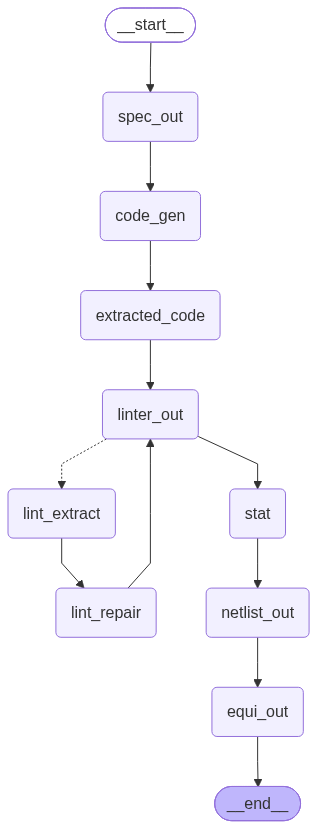

In [21]:
display(Image(builder.get_graph().draw_mermaid_png()))

In [22]:
input_state={"user_inp":"Design a 32 bit apb requester  with 100 Mhz operating frequency" }

resp=builder.invoke(input=input_state) # type: ignore

In [23]:
pprint(resp)

{'code_gen': '```verilog\n'
             'module apb_requester (\n'
             '  input clk,\n'
             '  input rst_n,\n'
             '  output [31:0] apb_paddr,\n'
             '  output apb_psel,\n'
             '  output apb_penable,\n'
             '  output apb_pwrite,\n'
             '  output [31:0] apb_pwdata,\n'
             '  input [31:0] apb_prdata,\n'
             '  input apb_pready,\n'
             '  input apb_pslverr\n'
             ');\n'
             '\n'
             'reg [31:0] addr_reg;\n'
             'reg [31:0] data_reg;\n'
             'reg [2:0] state;\n'
             '\n'
             'always @(posedge clk or negedge rst_n) begin\n'
             '  if (!rst_n)\n'
             "    state <= 3'b000; // IDLE\n"
             '  else begin\n'
             '    case (state)\n'
             "      3'b000: if (apb_pready) state <= 3'b001; // ADDR\n"
             "      3'b001: if (apb_pready) state <= 3'b010; // DATA\n"
             "      3'b010: if (apb_p